# Hard Istance Max Cut with different annealing methods

#### Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import get_driver_hamiltonian,get_longitudinal_hamiltonian,computational_basis
from src.schedule_utils import SchedulerModel,Schedule
from ManyBodyQutip.qutip_class import SpinOperator 
from src.utils import Sector

## Initialization of the target Hamiltonian

#### Hyperapameters

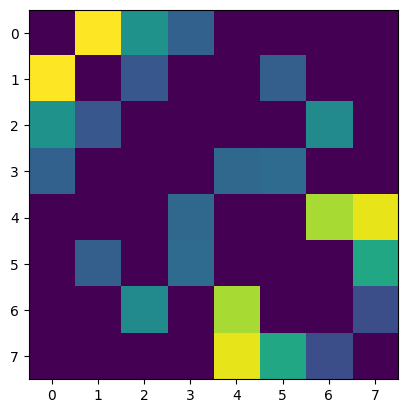

In [2]:
#### create istances on networkx
nqubits = 8

basis=computational_basis(nqubits)
graph_instance = nx.random_regular_graph(d=3, n=nqubits)

# Assign random weights in [0,1]
for u, v in graph_instance.edges():
    graph_instance[u][v]['weight'] = np.random.uniform(0, 1)
    
jij = nx.to_numpy_array(graph_instance)  # unweighted adjacency matrix

plt.imshow(jij)
plt.show()

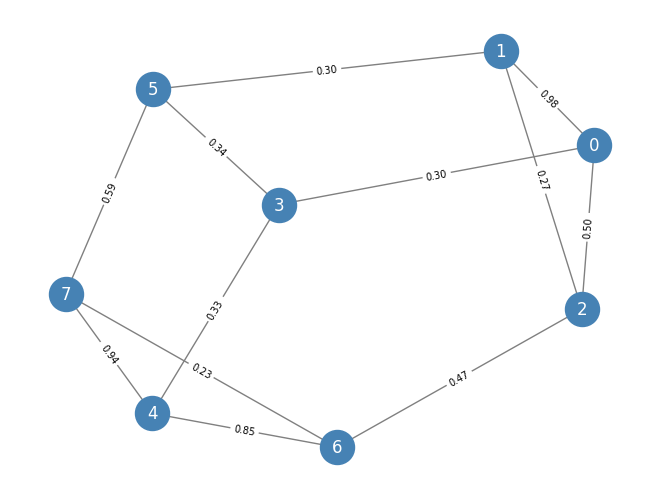

In [3]:

pos = nx.spring_layout(graph_instance, seed=42)
nx.draw(graph_instance, pos, with_labels=True, node_color='steelblue',
        edge_color='gray', node_size=600, font_color='white')

# draw edge weights
edge_labels = {(u,v): f"{graph_instance[u][v]['weight']:.2f}" for u,v in graph_instance.edges()}
nx.draw_networkx_edge_labels(graph_instance, pos, edge_labels=edge_labels, font_size=7)

plt.show()

#### Hamiltonian Initialization

In [4]:
nqubits=jij.shape[0]

PS=Sector(nqubits=nqubits)

target_hamiltonian=get_longitudinal_hamiltonian(jij)
target_hamiltonian_s=PS.project(target_hamiltonian)
driver_hamiltonian=get_driver_hamiltonian(nqubits=nqubits)

driver_hamiltonian_s=PS.project(driver_hamiltonian)


Sector: 128 states out of 256


#### Analysis of the spectrum of the target hamiltonian

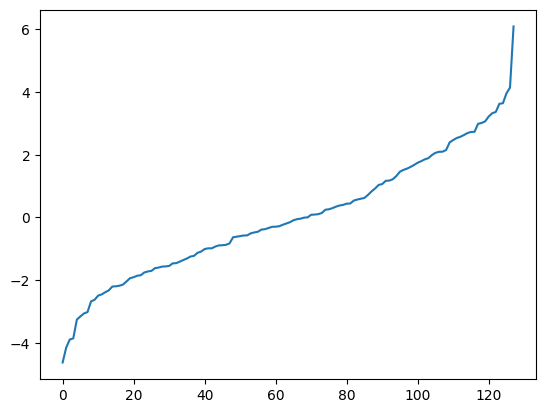

(-4.6251834667167975+0j) (-4.152582081408785+0j) [0 1 0 1 0 0 1 1] [0 1 1 1 0 0 1 1]


In [6]:
values=target_hamiltonian_s.diagonal()

spectrum_target_hamiltonian_s=np.sort(values)
eigenstates_target_hamiltonian_s=basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian_s)
plt.show()

print(spectrum_target_hamiltonian_s[0],spectrum_target_hamiltonian_s[1],eigenstates_target_hamiltonian_s[0],eigenstates_target_hamiltonian_s[1])

#### Time evolution

In [22]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels    = 10
tau        = 20
time_steps = int(10 * tau)
time       = np.linspace(0, tau, time_steps)
delta_t    = time[1] - time[0]

In [28]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)
print(psi_init.shape)
# ── initialization ────────────────────────────────────────────────────────────
spectrum            = np.zeros((time_steps, nlevels))
energy              = np.zeros(time_steps)
probabilities       = np.zeros((time_steps, nlevels))
psi_history          = np.zeros((time_steps, dim//2), dtype=complex)
eigenstates_history = np.zeros((time_steps, dim//2, nlevels), dtype=complex)

eigenstates_prev = None
psi = psi_init.copy()

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian_s + (t / tau) * target_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)


    # ── diagonalize ───────────────────────────────────────────────────────
    spectrum_t, eigenstates_t = eigsh(hamiltonian_t.astype(complex), which='SA', k=nlevels)
    order              = np.argsort(spectrum_t)
    spectrum[i]        = spectrum_t[order]
    eigenstates_raw    = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    eigenstates_history[i] = eigenstates_raw
    # overlap
    probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history[i] = psi

print(probabilities[-1])
print(spectrum.shape)
print(time[np.argmin(spectrum[:,2]-spectrum[:,0])],np.min(spectrum[:,2]-spectrum[:,0]))

min_time_gap= time[np.argmin(spectrum[:,2]-spectrum[:,0])]

(128,)


/tmp/ipykernel_92689/3541074027.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_raw)*np.einsum('i,ia->a',psi.conj(),eigenstates_raw).conj()


[5.93369583e-01 1.43349998e-01 1.81416733e-01 3.53663598e-02
 2.67031819e-02 1.28196682e-02 1.56376059e-03 3.25502978e-03
 6.34865991e-05 4.50781733e-04]
(200, 10)
14.974874371859297 0.5012135624943368


Check the results

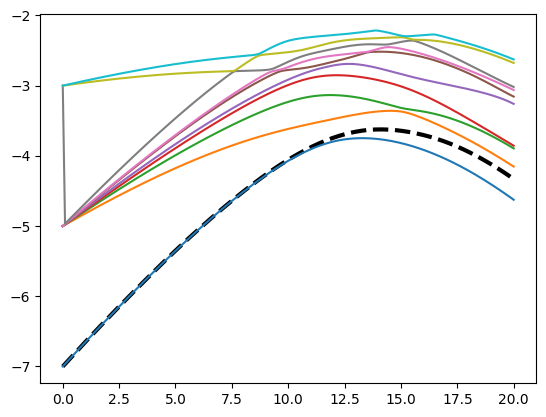

In [24]:

plt.plot(time,energy,color='black',linestyle='--',linewidth=3)
for i in range(spectrum.shape[1]):
        plt.plot(time,spectrum[:,i])

plt.show()

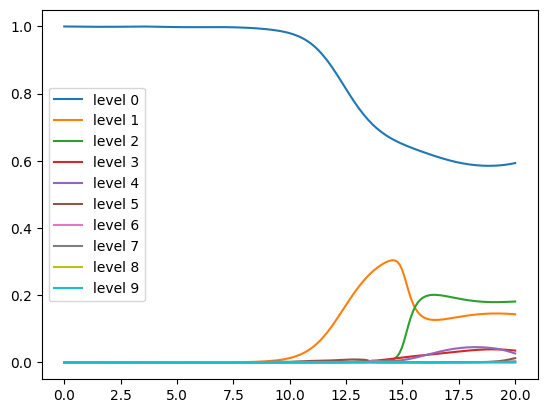

In [25]:
for i in range(nlevels):
    plt.plot(time,probabilities[:,i],label=f'level {i}')

plt.legend()
plt.show()

#### Compute Measure of Stabilizerness

In [29]:
from src.jax_utils import SREJax
from tqdm import trange

# build once — reuse for all states
sre = SREJax(n_qubits=nqubits, batch_size=4096)

# single state
magic=[]
magic_gs_level=[]
for i in trange(time_steps):
    state=psi_history[i]
    magic.append(sre(PS.lift(state)))
    magic_gs_level.append(sre(PS.lift(eigenstates_history[i,:,0])))

Building Pauli tables for n=8 (65536 Paulis)...
Done.


100%|██████████| 200/200 [00:50<00:00,  3.98it/s]


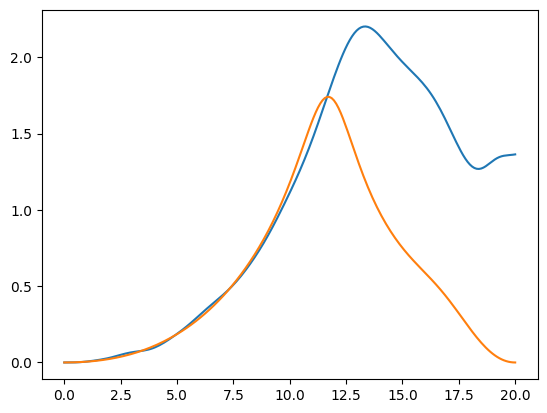

In [30]:
plt.plot(time,magic)
plt.plot(time,magic_gs_level)
plt.show()

In [31]:

from curses.ascii import SP


_,eigenstates_target_hamiltonian=eigsh(target_hamiltonian_s.astype(complex), which='SA', k=4)
print(sre(PS.lift(eigenstates_target_hamiltonian[:,0]))) 

0.0


## Optimal Control Method

##### Get Hyperparameters

In [32]:
number_parameters=3
type='F-CRAB'

In [33]:
from scipy.optimize import minimize

model=SchedulerModel(target_hamiltonian=target_hamiltonian_s,initial_hamiltonian=driver_hamiltonian_s,tf=tau,nsteps=time_steps,number_of_parameters=number_parameters,type=type,seed=42,reference_hamiltonian=target_hamiltonian_s,mode='annealing ansatz')



res = minimize(
                    model.forward,
                    model.parameters,
                    method='L-BFGS-B',
                    tol=10**-6,
                    callback=model.callback,
                    options=None,
                    
                )

model.parameters = res.x
energy = model.forward(model.parameters)

-4.4161821339242024
-4.441985833797421
-4.473204753487746
-4.483517771097711
-4.503364096852282
-4.512977479477913
-4.515814216735226
-4.524188098134634
-4.527183328260327
-4.587632678010444
-4.6008813645504265
-4.607015652555875
-4.610383023158113
-4.613219244873541
-4.615015288580515
-4.615616824507174
-4.6159768167271675
-4.616826970449345
-4.617948006429394
-4.618439478338905
-4.6193637894169415
-4.619609202598374
-4.619742342353353
-4.62002079517374
-4.620208276663115
-4.620534112712245
-4.620736222253961
-4.6208184405558
-4.620905197905121
-4.621000343372816
-4.62116793797452
-4.621258332298923
-4.621351914085138
-4.621473327257271
-4.621508551532308
-4.621713056416932
-4.621815370172726
-4.621883103306431
-4.621906236570339
-4.6219824489453565
-4.622093786044328
-4.622296244720215
-4.622368320594842
-4.6225538887213125
-4.622892077245093
-4.623097146069318
-4.623196819851955
-4.623311703650147
-4.623657317756261
-4.623813487197602
-4.623925595713714
-4.624013293727977
-4.6240730

#### Jax optimization (optional)

In [60]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model = JaxSchedulerModel(
    initial_state=psi_init,
    target_hamiltonian=target_hamiltonian,
    initial_hamiltonian=driver_hamiltonian,
    reference_hamiltonian=target_hamiltonian,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode='annealing ansatz',
    random=True,
)

trainer = JaxTrainer(model, maxiter=1000, tol=1e-6, ftol=1e-9, gtol=1e-6, verbose=True)
results = trainer.run()

h_driver  = results['h_driver']
h_target  = results['h_target']
psi_final = results['psi']
energy    = results['energy']   # already in physical units

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


KeyboardInterrupt: 

#### Check the results

(10.104500807688156+1.4579302082767482j)


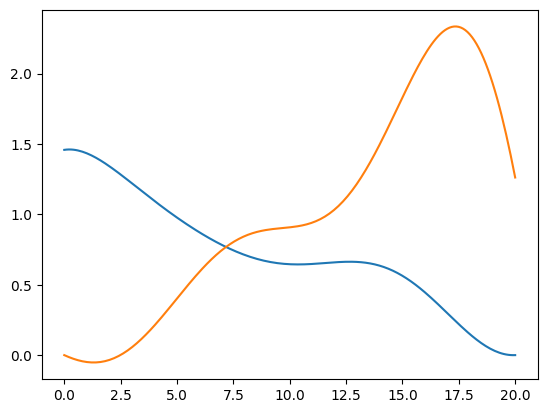

(-4.624813334573726+2.220446049250313e-16j)


In [34]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear  = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history  = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state
_, psi = eigsh(driver_hamiltonian_s.astype(complex), which='SA', k=1)
psi_init = psi[:, 0].astype(complex)
print(psi_init.dot(h_driver[0]*driver_hamiltonian_s.dot(psi_init)))

plt.plot(time,h_driver)
plt.plot(time,h_target)
plt.show()





# initialization
psi=psi_init.copy()
psi_history_optimalcontrol=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
for i,t in enumerate(time):
    
    hamiltonian_t=h_driver[i]*driver_hamiltonian_s+target_hamiltonian_s*h_target[i]
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    psi_history_optimalcontrol[i]=psi
    #for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian_s.dot(psi)))

In [37]:


# initialization
energy_optimal=np.zeros(time_steps)
probabilities_optimalcontrol=np.zeros((time_steps,nlevels))
spectrum_optimalcontrol=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_optimalcontrol[i]     
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i]=spectrum_t
    # overlap
    probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
    energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_optimalcontrol[-1,0])

/tmp/ipykernel_92689/2306226813.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_92689/2306226813.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i]=psi.conj().dot(hamiltonian_t.dot(psi))


20.0
(-4.624813334573726+2.220446049250313e-16j)
0.9997201302494261


In [38]:
print(spectrum_optimalcontrol[-1])

[-4.62518347 -4.15258208 -3.89372948 -3.85536899 -3.25933076 -3.15581191
 -3.0624156  -3.0189676  -2.67649493 -2.62626166]


0
-4.625183466716811
1
-4.152582081408803
2
-3.893729479544538
3
-3.8553689915892586
4
-3.2593307642281637
5
-3.155811909099695
6
-3.062415598402904
7
-3.018967597069245
8
-2.6764949267822282
9
-2.626261658110305


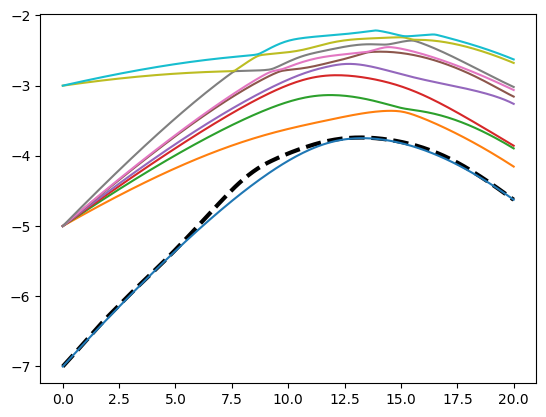

In [39]:

plt.plot(time,energy_optimal,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_optimalcontrol.shape[1]):
        print(i)
        print(spectrum_optimalcontrol[-1,i])
        plt.plot(time,spectrum_optimalcontrol[:,i])

plt.show()

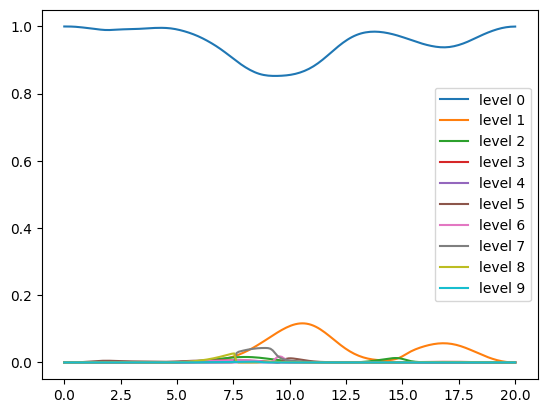

In [40]:
for i in range(nlevels):
    plt.plot(time,probabilities_optimalcontrol[:,i],label=f'level {i}')

plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [41]:
# single state
magic_optimal_control=[]
for i in trange(time_steps):
    state=psi_history_optimalcontrol[i]
    magic_optimal_control.append(sre(PS.lift(state)))

100%|██████████| 200/200 [00:26<00:00,  7.53it/s]


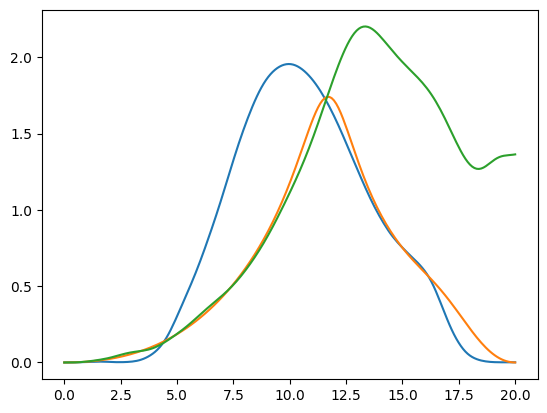

In [42]:
plt.plot(time,magic_optimal_control)
plt.plot(time,magic_gs_level)
plt.plot(time,magic)
plt.show()

## CounterAdiabatic Driving

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [45]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
counteradiabatic_term_s=PS.project(counteradiabatic_term)
print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 2048 stored elements and shape (256, 256)>
  Coords	Values
  (0, 1)	-3.5176288178828763j
  (0, 2)	-3.1035955399989277j
  (0, 4)	-2.447666329316492j
  (0, 8)	-4.237210024338472j
  (0, 16)	-1.9486885399345564j
  (0, 32)	-2.4659622141573765j
  (0, 64)	-3.0768117148458076j
  (0, 128)	-3.5561286971632624j
  (1, 0)	3.5176288178828763j
  (1, 3)	-2.170477363463j
  (1, 5)	-0.1035188551284758j
  (1, 9)	-0.47921803929666407j
  (1, 17)	-1.9486885399345573j
  (1, 33)	-2.465962214157377j
  (1, 65)	-3.0768117148458076j
  (1, 129)	-3.5561286971632624j
  (2, 0)	3.1035955399989277j
  (2, 3)	-2.5845106413469487j
  (2, 6)	-2.447666329316492j
  (2, 10)	-0.8364013945200179j
  (2, 18)	-1.9486885399345566j
  (2, 34)	-0.5926979405139026j
  (2, 66)	-3.076811714845807j
  (2, 130)	-3.556128697163262j
  (3, 1)	2.170477363463j
  :	:
  (252, 254)	2.170477363463j
  (253, 125)	-3.556128697163262j
  (253, 189)	-3.076811714845807j
  (253, 221)	-0.592697940

In [51]:
from scipy.sparse.linalg import eigsh,expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
psi_init=PS.project(psi_init)

# initialization

psi=psi_init.copy()
psi_history_counteradiabatic=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_counteradiabatic=np.zeros((time_steps,nlevels))
energy_counteradiabatic=np.zeros(time_steps)
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau+(1-t/tau)*(t/tau)*counteradiabatic_term_s
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_counteradiabatic[i]=spectrum_t
    energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_counteradiabatic[i]=psi


/tmp/ipykernel_92689/2861623005.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [52]:

# initialize the state


# initialization
energy_counteradiabatic_linear_hamiltonian=np.zeros(time_steps)
probabilities_counteradiabatic=np.zeros((time_steps,nlevels))
for i,t in enumerate(time):
    psi=psi_history_counteradiabatic[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian_s+target_hamiltonian_s*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()

    energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian_s.dot(psi)))
print(probabilities_counteradiabatic[-1,0])

/tmp/ipykernel_92689/2927563156.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_counteradiabatic[i]=np.einsum('i,ia->a',psi.conj(),eigenstates_t)*np.einsum('i,ia->a',psi.conj(),eigenstates_t).conj()
/tmp/ipykernel_92689/2927563156.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_counteradiabatic_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


20.0
(-4.5650180433926755-2.220446049250313e-16j)
0.9128540038197959


##### Results of the unbiased counteradiabatic term

0
-4.625183466716799
2
-3.8937294795445405
4
-3.259330764228148
6
-3.062415598402892
8
-2.676494926782242


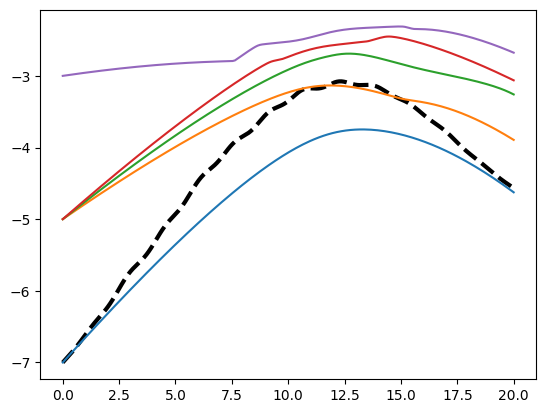

0
-4.625183466716804
2
-3.893729479544527
4
-3.2593307642281704
6
-3.0624155984029056
8
-2.676494926782243


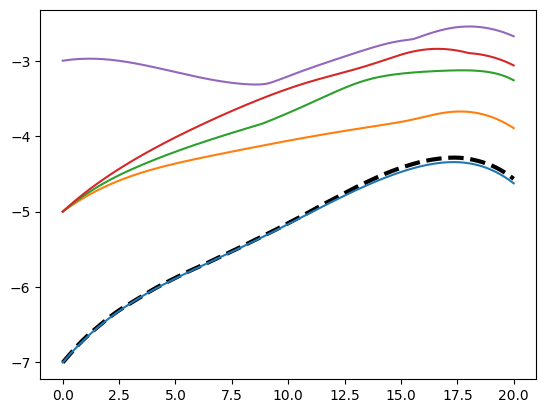

In [53]:

plt.plot(time,energy_counteradiabatic_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum[-1,i])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_counteradiabatic,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_counteradiabatic.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum_counteradiabatic[-1,i])
        plt.plot(time,spectrum_counteradiabatic[:,i])

plt.show()


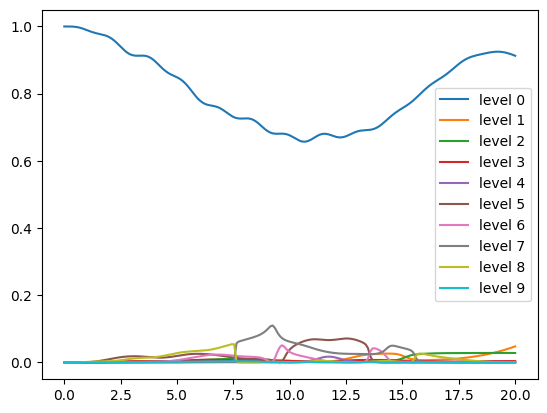

In [54]:
for i in range(nlevels):
    plt.plot(time,probabilities_counteradiabatic[:,i],label=f'level {i}')

plt.legend()
plt.show()

##### Measure of Stabilizerness

In [ ]:
# single state
magic_counteradiabatic=[]

for i in trange(time_steps):
    state=psi_history_counteradiabatic[i]
    magic_counteradiabatic.append(sre(PS.lift(state)))


## Catalyst Term

##### We should be more careful about the CounterAdiabatic Driving, we need to be sure on the structure

Let's initialize the Catalyst term

In [47]:
from src.annealing_utils import get_unbiased_catalyst_term
from src.annealing_utils import get_counteradiabatic_term
from ManyBodyQutip.qutip_class import SpinOperator

counteradiabatic_term=get_counteradiabatic_term(driver_hamiltonian=driver_hamiltonian,target_hamiltonian=target_hamiltonian)
#catalyst_term=get_unbiased_catalyst_term(nqubits=nqubits)
catalyst_term=SpinOperator(index=[('x',0,'x',nqubits-2)],coupling=[1.],size=nqubits).qutip_op.data_as('csr_matrix')

print(counteradiabatic_term)

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 2048 stored elements and shape (256, 256)>
  Coords	Values
  (0, 1)	-2.613077034202336j
  (0, 2)	-2.461921367287011j
  (0, 4)	-2.897776788056897j
  (0, 8)	-1.4190010125549208j
  (0, 16)	-3.5661178048657094j
  (0, 32)	-1.1395065604811117j
  (0, 64)	-2.1627217279081052j
  (0, 128)	-2.7321031512720424j
  (1, 0)	2.613077034202336j
  (1, 3)	-2.46192136728701j
  (1, 5)	-1.5081331158705567j
  (1, 9)	-1.4190010125549206j
  (1, 17)	0.022845255725195024j
  (1, 33)	-0.8919592248536836j
  (1, 65)	-2.162721727908105j
  (1, 129)	-2.732103151272042j
  (2, 0)	2.461921367287011j
  (2, 3)	-2.6130770342023357j
  (2, 6)	0.06574236692946345j
  (2, 10)	-0.9319334647575135j
  (2, 18)	-3.566117804865709j
  (2, 34)	-1.139506560481111j
  (2, 66)	-0.6894656961178518j
  (2, 130)	-2.7321031512720424j
  (3, 1)	2.46192136728701j
  :	:
  (252, 254)	2.46192136728701j
  (253, 125)	-2.7321031512720424j
  (253, 189)	-0.6894656961178518j
  (253, 221)	-1.1395

Tayloring the catalyst around the minimum gap

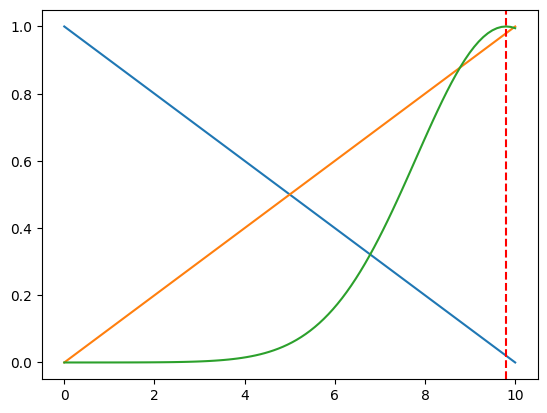

In [48]:
plt.plot(time,(1-time/tau))
plt.plot(time,time/tau)
sigma = 0.2   # width — tune this
catalyst_schedule = np.exp(-0.5 * ((time / tau - (min_time_gap)/tau) / sigma) ** 2)
plt.axvline(x=min_time_gap, color='red', linestyle='--', label='Min Gap Time')
plt.plot(time,catalyst_schedule)
plt.show()

In [60]:
from scipy.sparse.linalg import eigsh,expm_multiply

# ── initial state ─────────────────────────────────────────────────────────────
dim      = 2 ** nqubits
psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)


# initialization

psi=psi_init
psi_history_catalyst=np.zeros((time_steps, psi_init.shape[0]), dtype=complex)
spectrum_catalyst=np.zeros((time_steps,nlevels))
energy_catalyst=np.zeros(time_steps)
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau+(1-t/tau)*(t/tau)*catalyst_term
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    order = np.argsort(spectrum_t)
    spectrum_t    = spectrum_t[order]
    spectrum_catalyst[i]=spectrum_t
    energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    # sort both by eigenvalue
    psi_history_catalyst[i]=psi


/tmp/ipykernel_80040/743221965.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst[i]=psi.conj().dot(hamiltonian_t.dot(psi))


In [58]:

# initialize the state


# initialization
energy_catalyst_linear_hamiltonian=np.zeros(time_steps)
probabilities_catalyst=np.zeros((time_steps,nlevels//2))
for i,t in enumerate(time):
    psi=psi_history_catalyst[i]     
    hamiltonian_t_linear=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau
    values, eigenstates = eigsh(hamiltonian_t_linear, which='SA', k=nlevels)
    order = np.argsort(values)
    spectrum_t    = values[order]
    eigenstates_t = eigenstates[:, order]
    # overlap
    overlap_t=np.einsum('i,ia->a',psi.conj(),eigenstates_t)
    for r in range(n_subspaces):
        probabilities_catalyst[i,r]=np.sum(((overlap_t[r*2:(r+1)*2])*(overlap_t[r*2:(r+1)*2]).conj()).real)
    
    energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_catalyst[-1,0])

/tmp/ipykernel_80040/4061078792.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_catalyst_linear_hamiltonian[i]=psi.conj().dot(hamiltonian_t_linear.dot(psi))


10.0
(-3.6324560068402514+2.220446049250313e-16j)
0.2853834343069497


##### Results of the unbiased catalyst

0
-3.9909786558618667
2
-3.9510044159580375
4
-3.878559959173675
6
-3.0590451911043504
8
-2.9548765288788927


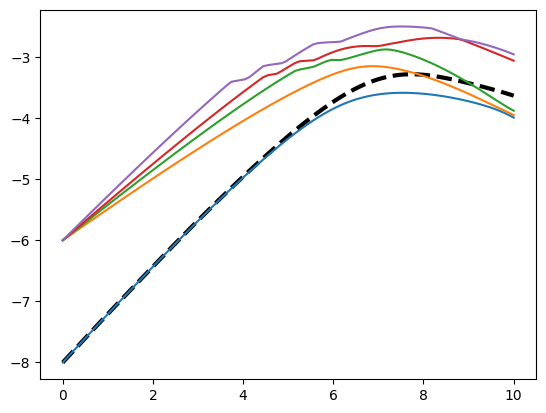

0
-3.990978655861878
2
-3.9510044159580375
4
-3.878559959173677
6
-3.0590451911043464
8
-2.9548765288788905


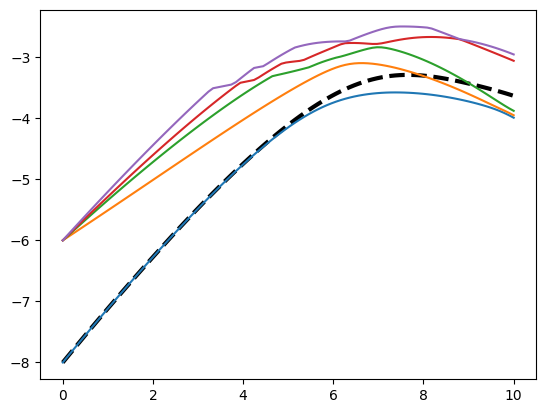

In [59]:

plt.plot(time,energy_catalyst_linear_hamiltonian,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum[-1,i])
        plt.plot(time,spectrum[:,i])

plt.show()

plt.plot(time,energy_catalyst,color='black',linestyle='--',linewidth=3)
for i in range(spectrum_catalyst.shape[1]):
    if i%2==0:
        print(i)
        print(spectrum_catalyst[-1,i])
        plt.plot(time,spectrum_catalyst[:,i])

plt.show()


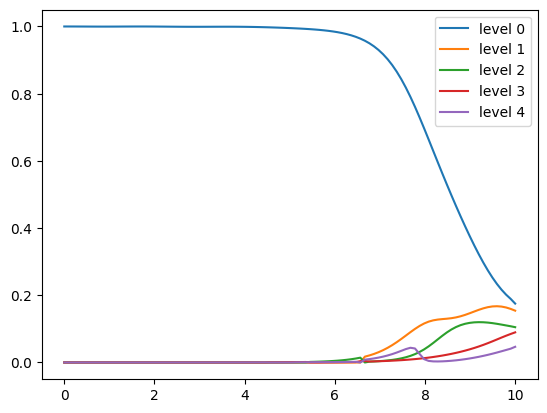

In [95]:
for i in range(nlevels//2):
    plt.plot(time,probabilities_catalyst[:,i],label=f'level {i}')

plt.legend()
plt.show()